# Using CART Decision Tree to Predict Experience Level

Based on previous analysis, we've switched the target variable to `Experience_Level` to ensure the model learns actual patterns instead of random noise.

This notebook demonstrates a CART model with Training, Validation, and Testing pipelines.

### 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

df = pd.read_csv('Dataset/gym_members_exercise_tracking.csv')
display(df.head())


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


### 2. Preprocessing & Splitting
Encode categorical variables and perform the 60-20-20 split.

In [ ]:
# Encode Gender
le_gender = LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

# Define Features (X) and Target (y)
X = df.drop(columns=['Experience_Level', 'Workout_Type'])
y = df['Experience_Level']

# Split 1: 80% Temp, 20% Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Split 2: 60% Train, 20% Validation (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")


Train: 743 | Validation: 132 | Test: 98


### 3. Build & Validate CART Model

In [ ]:
cart_model = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
cart_model.fit(X_train, y_train)

# Validation Pipeline
val_preds = cart_model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_preds):.2f}")

Validation Accuracy: 0.89


### 4. Testing & Evaluation Pipeline

In [ ]:
test_preds = cart_model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.2f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_preds))

Test Accuracy: 0.91

Classification Report:

              precision    recall  f1-score   support

           1       0.94      0.82      0.88        40
           2       0.83      0.94      0.88        36
           3       1.00      1.00      1.00        22

    accuracy                           0.91        98
   macro avg       0.92      0.92      0.92        98
weighted avg       0.91      0.91      0.91        98



### 5. Visualizations

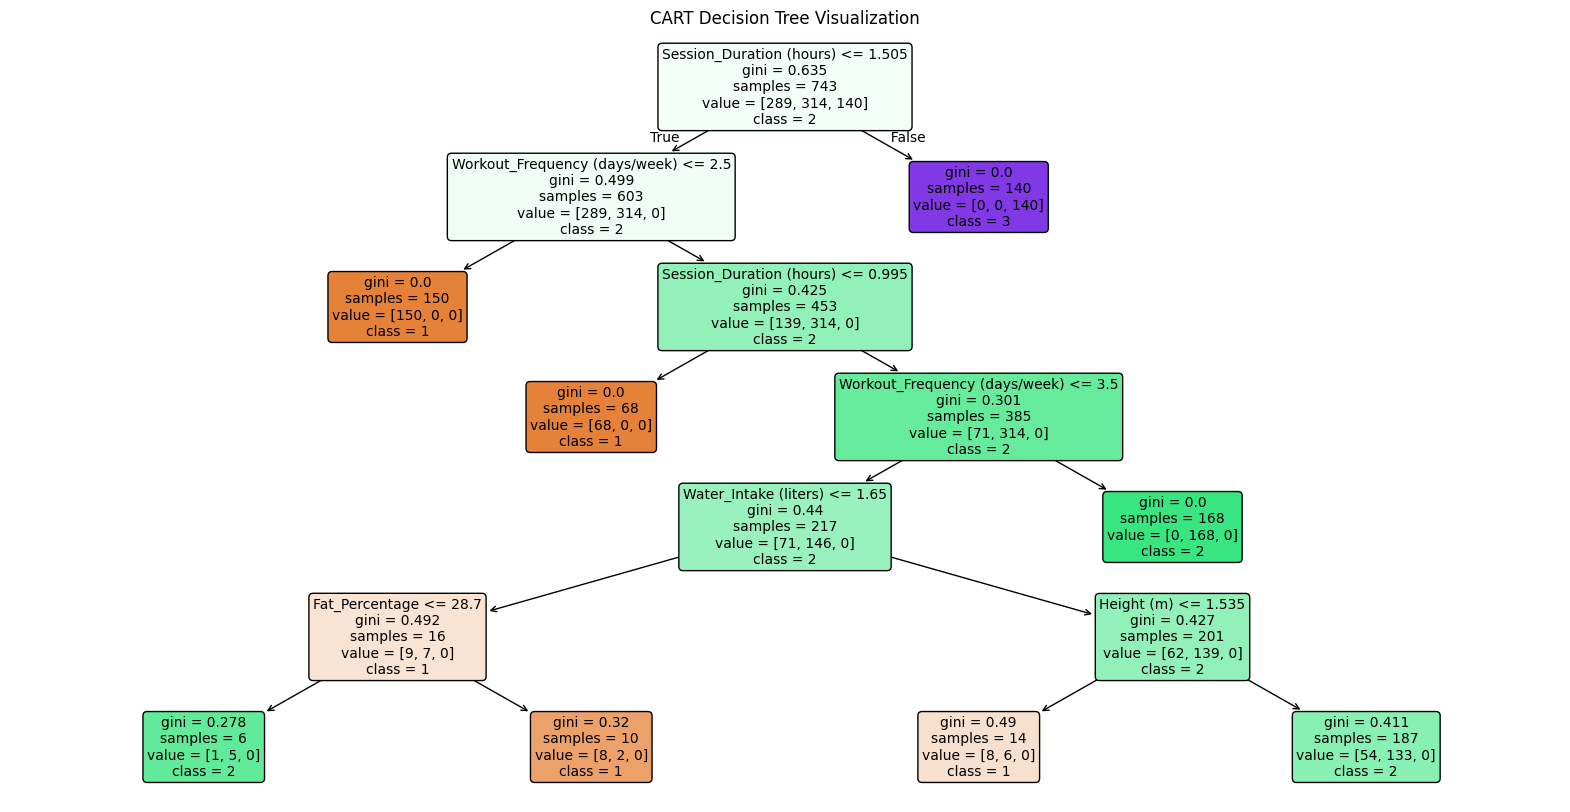

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(cart_model, feature_names=X.columns, class_names=[str(c) for c in cart_model.classes_], filled=True, rounded=True, fontsize=10)
plt.title("CART Decision Tree Visualization")
plt.show()

Confusion Matrix:

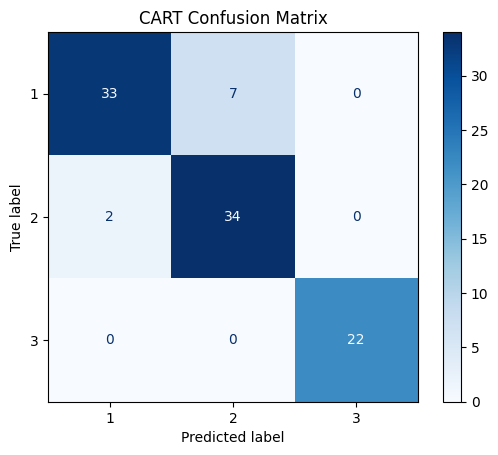

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, test_preds, cmap='Blues')
plt.title("CART Confusion Matrix")
plt.show()

In [8]:
# --- TEST FRAGMENT: CART SANITY CHECKS ---
print("Running CART Pipeline Tests...")

# Test 1: Check if the model is actually fitted
assert hasattr(cart_model, "classes_"), "Test Failed: CART model is not fitted."

# Test 2: Single Observation Prediction Check (Dimension Check)
single_test_row = X_test.iloc[[0]]
single_prediction = cart_model.predict(single_test_row)
assert len(single_prediction) == 1, f"Test Failed: Expected 1 prediction, got {len(single_prediction)}"

# Test 3: Output Type Check
assert isinstance(single_prediction[0].item(), (int, float, str)), f"Test Failed: Prediction format is unrecognized. Got {type(single_prediction[0])}"

# Test 4: Accuracy Boundary Check
test_acc = accuracy_score(y_test, test_preds)
assert 0.0 <= test_acc <= 1.0, f"Test Failed: Accuracy out of bounds ({test_acc})"

print("✅ All CART tests passed successfully!")

Running CART Pipeline Tests...
✅ All CART tests passed successfully!


In [9]:
# --- FINAL AUDIT & TEST REPORT: CART MODEL ---
print("==================================================")
print("          CART PIPELINE AUDIT REPORT              ")
print("==================================================")

# 1. Model Fitting Check
assert hasattr(cart_model, "classes_"), "CRITICAL ERROR: CART model is not fitted."
print("[X] Model successfully fitted to training data.")

# 2. Dimension & Format Check
single_test_row = X_test.iloc[[0]]
single_prediction = cart_model.predict(single_test_row)
assert len(single_prediction) == 1, f"CRITICAL ERROR: Expected 1 prediction, got {len(single_prediction)}"
assert isinstance(single_prediction[0].item(), (int, float, str)), f"CRITICAL ERROR: Prediction format unrecognized."
print(f"[X] Single-row prediction formatting validated (Type: {type(single_prediction[0].item()).__name__}).")

# 3. Accuracy Boundaries & Final Metrics
test_acc = accuracy_score(y_test, test_preds)
assert 0.0 <= test_acc <= 1.0, f"CRITICAL ERROR: Accuracy out of bounds ({test_acc})"
print("[X] Accuracy metric boundaries validated.")

print("--------------------------------------------------")
print(f"Total Test Records Evaluated : {len(y_test)}")
print(f"Final CART Model Accuracy    : {test_acc:.4f} ({test_acc * 100:.2f}%)")
print("==================================================")
print("✅ ALL PIPELINE TESTS PASSED SUCCESSFULLY.")

          CART PIPELINE AUDIT REPORT              
[X] Model successfully fitted to training data.
[X] Single-row prediction formatting validated (Type: int).
[X] Accuracy metric boundaries validated.
--------------------------------------------------
Total Test Records Evaluated : 98
Final CART Model Accuracy    : 0.9082 (90.82%)
✅ ALL PIPELINE TESTS PASSED SUCCESSFULLY.
